# PyTorch — framework essentials

**Objectifs :**
- comprendre les `Tensor` ;
- utiliser `Autograd` ;
- construire un modèle avec `nn.Module` ;
- définir un `Loss` et un `Optimizer` ;
- écrire une boucle d’apprentissage ;
- distinguer `train()` et `eval()` ;
- utiliser `Dataset` / `DataLoader` ;
- entraîner un exemple de régression et un exemple de classification ;
- sauvegarder et recharger un modèle.

## 0. Préparation

Le notebook fonctionne sur CPU. S’il existe un GPU CUDA, PyTorch pourra l’utiliser automatiquement.

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

PyTorch version: 2.6.0
CUDA disponible: True


## 1. Workflow général

Le cycle de base est :

**Données → Tensors → Modèle → Prédictions → Loss → Backward → Optimizer → Mise à jour**

In [5]:
# Pseudo-code de la logique générale
# y_pred = model(X)
# loss = criterion(y_pred, y)
# optimizer.zero_grad()
# loss.backward()
# optimizer.step()

## 2. Les Tensors

Un `Tensor` est la structure de données fondamentale de PyTorch.

In [6]:
scalar = torch.tensor(3.0)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print("scalar:", scalar, "shape =", scalar.shape)
print("vector:", vector, "shape =", vector.shape)
print("matrix:", matrix, "shape =", matrix.shape)
print("dtype:", matrix.dtype)
print("ndim:", matrix.ndim)

scalar: tensor(3.) shape = torch.Size([])
vector: tensor([1., 2., 3.]) shape = torch.Size([3])
matrix: tensor([[1., 2.],
        [3., 4.]]) shape = torch.Size([2, 2])
dtype: torch.float32
ndim: 2


### Manipulation de Tensors

In [7]:
x = torch.arange(12)
print("x =", x)

x2 = x.reshape(3, 4)
print("reshape(3,4):", x2)

print("Colonne 1:", x2[:, 1])
print("Ligne 0:", x2[0, :])

A = torch.tensor([[1., 2.], [3., 4.]])
B = torch.tensor([[2., 0.], [1., 2.]])
print("A @ B =", A @ B)

print("mean(A) =", A.mean())
print("sum(A) =", A.sum())

x = tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
reshape(3,4): tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Colonne 1: tensor([1, 5, 9])
Ligne 0: tensor([0, 1, 2, 3])
A @ B = tensor([[ 4.,  4.],
        [10.,  8.]])
mean(A) = tensor(2.5000)
sum(A) = tensor(10.)


## 3. CPU, GPU et `device`

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé:", device)

x = torch.tensor([1.0, 2.0, 3.0]).to(device)
print("x.device =", x.device)

Device utilisé: cuda
x.device = cuda:0


## 4. Autograd

`Autograd` calcule automatiquement les dérivées à partir du graphe de calcul.

In [9]:
x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x + b
loss = (y - 10) ** 2

loss.backward()

print("y =", y.item())
print("loss =", loss.item())
print("dLoss/dw =", w.grad.item())
print("dLoss/db =", b.grad.item())

y = 7.0
loss = 9.0
dLoss/dw = -12.0
dLoss/db = -6.0


In [10]:
import torch

x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x + b
loss = (y - 10) ** 2

dw, db = torch.autograd.grad(loss, (w, b))

print("y =", y.item())
print("loss =", loss.item())
print("dLoss/dw =", dw.item())
print("dLoss/db =", db.item())

y = 7.0
loss = 9.0
dLoss/dw = -12.0
dLoss/db = -6.0


### Vérification analytique

Ici :

### Vérification analytique

Ici :

$$y = wx+b$$

et

$$L=(y-10)^2$$

Donc :

$$\frac{\partial L}{\partial w}=2(y-10)x$$

$$\frac{\partial L}{\partial b}=2(y-10)$$


In [11]:
y_val = (3.0 * 2.0 + 1.0)
dL_dw = 2 * (y_val - 10) * 2.0
dL_db = 2 * (y_val - 10)
print(dL_dw, dL_db)

-12.0 -6.0


## 5. Un neurone avec `nn.Linear`

Un neurone linéaire calcule essentiellement :

$$z = \sum_i w_i x_i + b$$


In [12]:
model = nn.Linear(3, 1)
x = torch.tensor([[1.0, 2.0, 3.0]])
y = model(x)

print("Sortie:", y)
print("Poids:", model.weight)
print("Biais:", model.bias)

Sortie: tensor([[1.4977]], grad_fn=<AddmmBackward0>)
Poids: Parameter containing:
tensor([[ 0.4201, -0.0396,  0.3435]], requires_grad=True)
Biais: Parameter containing:
tensor([0.1262], requires_grad=True)


In [13]:
import torch
import torch.nn as nn
from torchviz import make_dot

model = nn.Linear(3, 1)
x = torch.tensor([[1.0, 2.0, 3.0]])
y = model(x)

print("Sortie:", y)
print("Poids:", model.weight)
print("Biais:", model.bias)

dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("graphe_operations", format="png", cleanup=True)

Sortie: tensor([[1.3844]], grad_fn=<AddmmBackward0>)
Poids: Parameter containing:
tensor([[ 0.4324,  0.4778, -0.0707]], requires_grad=True)
Biais: Parameter containing:
tensor([0.2086], requires_grad=True)


'graphe_operations.png'

## 6. Construire un réseau avec `nn.Module`

In [14]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


In [15]:
model = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )
print(model)

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=3, bias=True)
)


## 7. Fonctions d’activation

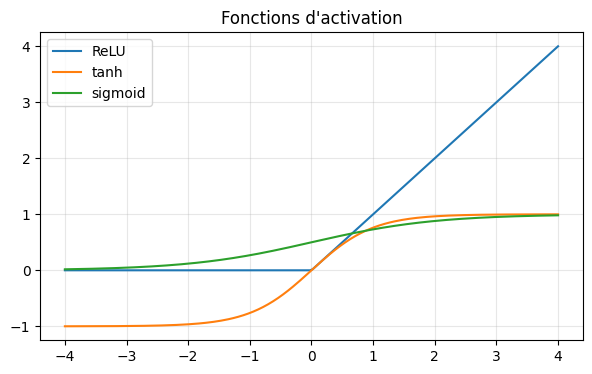

In [16]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import matplotlib.pyplot as plt

x = torch.linspace(-4, 4, 200)
relu = torch.relu(x)
tanh = torch.tanh(x)
sigmoid = torch.sigmoid(x)

plt.figure(figsize=(7,4))
plt.plot(x.numpy(), relu.numpy(), label='ReLU')
plt.plot(x.numpy(), tanh.numpy(), label='tanh')
plt.plot(x.numpy(), sigmoid.numpy(), label='sigmoid')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Fonctions d'activation")
plt.show()

## 8. Forward propagation

L’appel `model(X)` déclenche automatiquement `model.forward(X)`.

In [17]:
X = torch.randn(5, 4)
# L’appel model(X) déclenche automatiquement model.forward(X)
predicted = model(X)
print("Shape entrée :", X.shape)
print("Shape sortie :", predicted.shape)

Shape entrée : torch.Size([5, 4])
Shape sortie : torch.Size([5, 3])


## 9. Fonctions de coût

Cas principaux :
- régression : `nn.MSELoss()` ;
- classification multi-classe : `nn.CrossEntropyLoss()` ;
- classification binaire : `nn.BCEWithLogitsLoss()`.

In [18]:
# Régression
criterion_reg = nn.MSELoss()
y_pred = torch.tensor([[2.0], [4.0]])
y_true = torch.tensor([[3.0], [5.0]])
print("MSE =", criterion_reg(y_pred, y_true).item())

# Classification multi-classe
criterion_cls = nn.CrossEntropyLoss()
pred = torch.tensor([[2.0, 1.0, 0.5], [0.2, 0.1, 2.0]])
y = torch.tensor([0, 2])
print("CrossEntropy =", criterion_cls(pred, y).item())

MSE = 1.0
CrossEntropy = 0.36905235052108765


## 10. Optimizers

L’optimiseur utilise les gradients pour mettre à jour les paramètres.

In [19]:
simple_model = nn.Linear(1, 1)
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-2)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


## 11. La boucle d’apprentissage

C’est le cœur de PyTorch.

In [20]:
X = torch.randn(8, 1)
y = 2 * X + 1
simple_model = nn.Linear(1, 1)
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-2)
criterion = nn.MSELoss()
epochs = 500
# Exemple générique
for epoch in range(epochs):
    simple_model.train()
    y_pred = simple_model(X)
    loss = criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 ==0 : 
        print(f"epoch={epoch} loss={loss.item():.4f}")

epoch=0 loss=6.5186
epoch=100 loss=1.4897
epoch=200 loss=0.2435
epoch=300 loss=0.0324
epoch=400 loss=0.0031


## 12. `train()` vs `eval()`

`model.train()` et `model.eval()` influencent notamment le comportement de `Dropout` et `BatchNorm`.

`eval()` ne désactive pas le calcul des gradients. Pour l’inférence, on utilise généralement `torch.inference_mode()`.

In [21]:
class DropoutDemo(nn.Module):
    def __init__(self):
        super().__init__()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        return self.dropout(x)

m = DropoutDemo()
x = torch.ones(10)

m.train()
print("train() :", m(x))

m.eval()
with torch.inference_mode():
    print("eval()  :", m(x))

train() : tensor([0., 0., 2., 0., 0., 0., 2., 0., 0., 2.])
eval()  : tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## 13. Dataset et DataLoader

In [22]:
X = torch.randn(100, 3)
y = torch.randn(100, 1)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

for X_batch, y_batch in loader:
    print("Batch X:", X_batch.shape, "Batch y:", y_batch.shape)
    break

Batch X: torch.Size([16, 3]) Batch y: torch.Size([16, 1])


# Partie pratique 1 — Régression linéaire

Nous générons des données proches de :

\[
y = 3x + 2 + bruit
\]

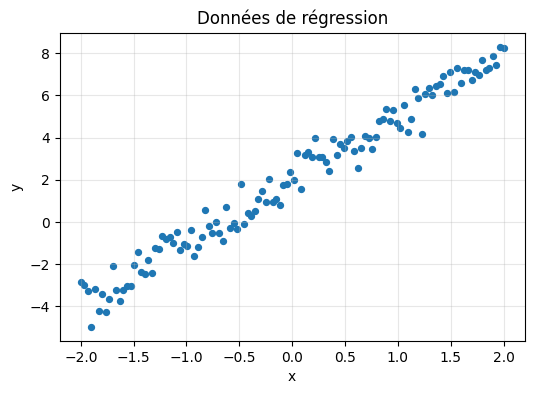

In [23]:
torch.manual_seed(42)

X = torch.linspace(-2, 2, 120).unsqueeze(1)
noise = 0.6 * torch.randn_like(X)
y = 3 * X + 2 + noise

plt.figure(figsize=(6,4))
plt.scatter(X.numpy(), y.numpy(), s=18)
plt.title("Données de régression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

## 14. Modèle, loss et optimizer

In [24]:
model_reg = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.05)

## 15. Entraînement de la régression

In [25]:
losses = []

for epoch in range(300):
    model_reg.train()

    y_pred = model_reg(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

print("Dernier loss:", losses[-1])
print("w appris:", model_reg.weight.item())
print("b appris:", model_reg.bias.item())

Dernier loss: 0.3438417613506317
w appris: 2.9894580841064453
b appris: 2.030014991760254


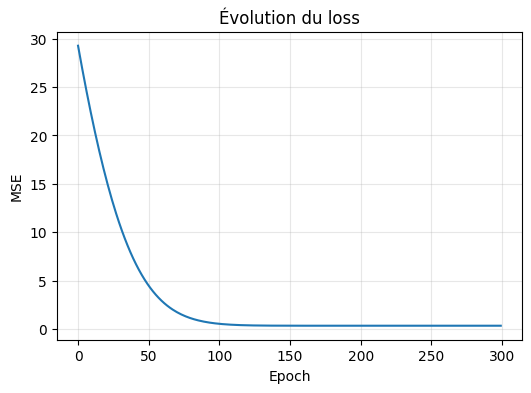

In [26]:
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Évolution du loss")
plt.grid(True, alpha=0.3)
plt.show()

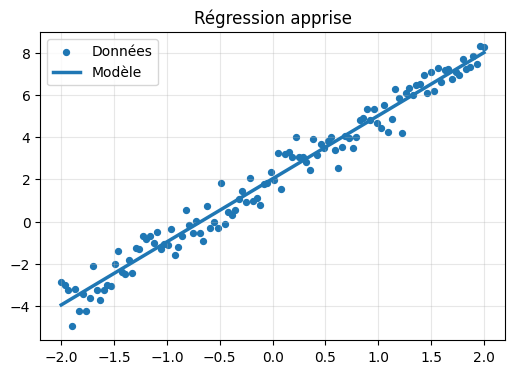

In [27]:
model_reg.eval()
with torch.inference_mode():
    y_hat = model_reg(X)

plt.figure(figsize=(6,4))
plt.scatter(X.numpy(), y.numpy(), s=18, label="Données")
plt.plot(X.numpy(), y_hat.numpy(), linewidth=2.5, label="Modèle")
plt.legend()
plt.title("Régression apprise")
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
from torcheval.metrics import R2Score
metric = R2Score()
metric.update(y_hat,y)
r2=metric.compute()
print(f"R2 Score = {r2:.3f}")

R2 Score = 0.972


# Partie pratique 2 — Classification

Créons deux classes de points en 2D.

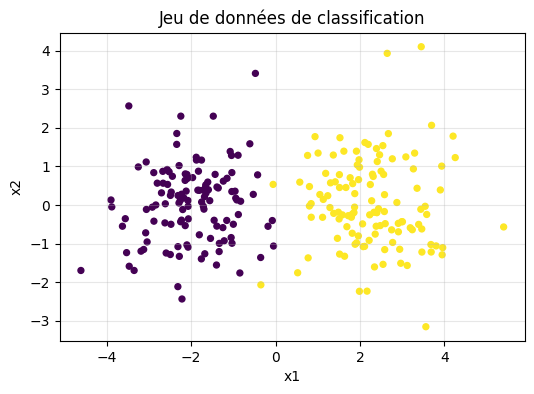

In [30]:
torch.manual_seed(0)

n = 120
class0 = torch.randn(n, 2) + torch.tensor([-2.0, 0.0])
class1 = torch.randn(n, 2) + torch.tensor([ 2.0, 0.0])

X_cls = torch.cat([class0, class1], dim=0)
y_cls = torch.cat([
    torch.zeros(n, dtype=torch.long),
    torch.ones(n, dtype=torch.long)
])

plt.figure(figsize=(6,4))
plt.scatter(X_cls[:,0], X_cls[:,1], c=y_cls, s=18)
plt.title("Jeu de données de classification")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()

## 16. Modèle de classification

In [31]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.net(x)

model_cls = Classifier()
criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(model_cls.parameters(), lr=0.01)

## 17. Entraînement de la classification

In [32]:
losses_cls = []

for epoch in range(250):
    model_cls.train()

    logits = model_cls(X_cls)
    loss = criterion_cls(logits, y_cls)

    optimizer_cls.zero_grad()
    loss.backward()
    optimizer_cls.step()

    losses_cls.append(loss.item())

print("Dernier loss:", losses_cls[-1])

Dernier loss: 0.0006943688495084643


In [33]:
model_cls.eval()
with torch.inference_mode():
    logits = model_cls(X_cls)
    pred = logits.argmax(dim=1)
    accuracy = (pred == y_cls).float().mean()

print(f"Accuracy = {accuracy.item()*100:.2f}%")

Accuracy = 100.00%


Accuracy = 1.0000, recall= 1.0000, precision=1.0000, f1score=1.0000
tensor([[120,   0],
        [  0, 120]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

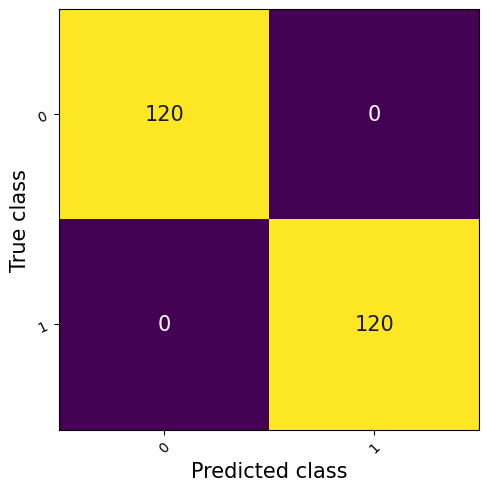

In [35]:
from torcheval.metrics import BinaryAccuracy, BinaryRecall, BinaryPrecision, BinaryPrecision, BinaryF1Score
from torchmetrics.classification import MulticlassConfusionMatrix, BinaryConfusionMatrix
accuracy_metric = BinaryAccuracy()
accuracy_metric.update(y_cls,pred)
accuracy_value = accuracy_metric.compute()

recall_metric = BinaryRecall()
recall_metric.update(y_cls, pred)
recall_value = recall_metric.compute()

precision_metric = BinaryPrecision()
precision_metric.update(y_cls,pred)
precision_value = precision_metric.compute()

f1_score_metric = BinaryF1Score()
f1_score_metric.update(y_cls, pred)
f1_score_value = f1_score_metric.compute()
print(f"Accuracy = {accuracy_value:.4f}, recall= {recall_value:.4f}, precision={precision_value:.4f}, f1score={f1_score_value:.4f}")

metric = BinaryConfusionMatrix()
confusion_matrix = metric(pred, y_cls)
print(confusion_matrix)
metric.plot()

## Visualisation de la frontière de décision

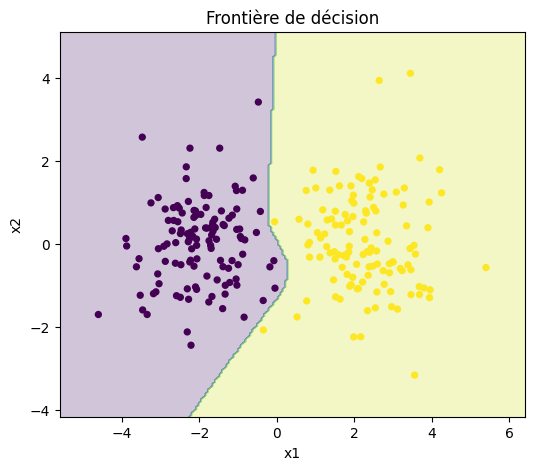

In [36]:
x1_min, x1_max = X_cls[:,0].min()-1, X_cls[:,0].max()+1
x2_min, x2_max = X_cls[:,1].min()-1, X_cls[:,1].max()+1

xx1, xx2 = torch.meshgrid(
    torch.linspace(x1_min, x1_max, 200),
    torch.linspace(x2_min, x2_max, 200),
    indexing='ij'
)

grid = torch.stack([xx1.reshape(-1), xx2.reshape(-1)], dim=1)

model_cls.eval()
with torch.inference_mode():
    zz = model_cls(grid).argmax(dim=1).reshape(xx1.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx1.numpy(), xx2.numpy(), zz.numpy(), alpha=0.25)
plt.scatter(X_cls[:,0], X_cls[:,1], c=y_cls, s=18)
plt.title("Frontière de décision")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 18. Sauvegarder et recharger un modèle

In [37]:
path = "classifier_state_dict.pt"
torch.save(model_cls.state_dict(), path)
print("Modèle sauvegardé dans", path)

new_model = Classifier()
new_model.load_state_dict(torch.load(path, weights_only=True))
new_model.eval()

with torch.inference_mode():
    pred_new = new_model(X_cls).argmax(dim=1)

print("Prédictions identiques:", torch.equal(pred, pred_new))

Modèle sauvegardé dans classifier_state_dict.pt
Prédictions identiques: True


# Synthèse

Les briques essentielles de PyTorch sont maintenant en place :

1. `Tensor`
2. `nn.Module`
3. `forward()`
4. fonction de coût
5. `optimizer.zero_grad()`
6. `loss.backward()`
7. `optimizer.step()`
8. `train()` / `eval()`
9. `Dataset` / `DataLoader`
10. sauvegarde avec `state_dict()`

Cette mécanique reste pratiquement la même pour des modèles plus avancés : CNN, Transformers, modèles génératifs ou PINNs.

# Exercices

### Exercice 1 : Régression

Prédire le salaire selon l’ancienneté et le niveau d’expertise

Objectif:

Construire un modèle de régression linéaire multiple pour prédire le salaire mensuel à partir de deux variables :
- Ancienneté : nombre d’années d’expérience.
- Niveau d’expertise : note de 1 à 5.
Le modèle doit apprendre la relation :

Salaire = w_1 * Ancienneté + w_2 * Expertise + b 

Les salaires sont exprimés en dirhams (DH). Les données sont fictives et servent uniquement à l’apprentissage.

1. *Générer les données*

Pour cet exercice, on suppose que les salaires suivent approximativement la règle : Salaire = 4000 + 600 * Ancienneté + 1500 * Expertise} + Bruit
Le bruit représente les variations individuelles non expliquées par les deux variables.

In [38]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Nombre de salariés
n = 300

# Ancienneté : de 0 à 20 ans
anciennete = torch.randint(0, 21, (n, 1)).float()

# Expertise : de 1 à 5
expertise = torch.randint(1, 6, (n, 1)).float()

# Variations aléatoires des salaires
bruit = torch.randn(n, 1) * 500

# Salaire mensuel en DH
salaires = (
    4000
    + 600 * anciennete
    + 1500 * expertise
    + bruit
)

# Matrice des entrées : dimensions (300, 2)
X = torch.cat([anciennete, expertise], dim=1)

# Sortie : dimensions (300, 1)
y = salaires

for i in range(5):
    print(
        f"Ancienneté : {X[i, 0].item():.0f} ans | "
        f"Expertise : {X[i, 1].item():.0f}/5 | "
        f"Salaire : {y[i, 0].item():.2f} DH"
    )

Ancienneté : 15 ans | Expertise : 2/5 | Salaire : 16262.90 DH
Ancienneté : 2 ans | Expertise : 3/5 | Salaire : 10541.39 DH
Ancienneté : 4 ans | Expertise : 3/5 | Salaire : 10948.37 DH
Ancienneté : 19 ans | Expertise : 3/5 | Salaire : 20028.54 DH
Ancienneté : 18 ans | Expertise : 2/5 | Salaire : 18036.38 DH


**Travail demandé**

- Affichez les dimensions de X et de y.
- Calculez le salaire moyen.
- Tracez un nuage de points représentant le salaire selon l’ancienneté, avec une couleur différente selon l’expertise.


2. *Séparer et préparer les données*
Utilisez 80 % des données pour l’entraînement et 20 % pour le test.

Pour faciliter l’apprentissage :

standardisez les entrées à partir des statistiques du jeu d’entraînement ;
exprimez les salaires en milliers de DH.

Dimensions X : torch.Size([300, 2])
Dimensions y : torch.Size([300, 1])
Salaire moyen : 15010.55 DH


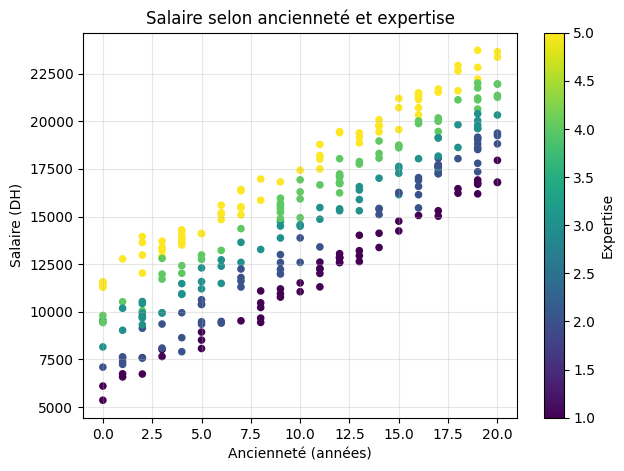

In [ ]:
indices = torch.randperm(n)
limite = int(0.8 * n)

train_indices = indices[:limite]
test_indices = indices[limite:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices] / 1000
y_test = y[test_indices] / 1000

# Statistiques calculées uniquement sur le jeu d'entraînement
moyenne = X_train.mean(dim=0, keepdim=True)
ecart_type = X_train.std(dim=0, keepdim=True)

X_train_norm = (X_train - moyenne) / ecart_type
X_test_norm = (X_test - moyenne) / ecart_type

#  Affichage des dimensions du jeu de données et calcul du salaire moyen.

print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)
print(f"Salaire moyen : {y.mean().item():.2f} DH")

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X[:, 0].numpy(),          # ancienneté
    y[:, 0].numpy(),          # salaire
    c=X[:, 1].numpy(),        # expertise
    cmap="viridis",
    s=20
)
plt.colorbar(scatter, label="Expertise")
plt.xlabel("Ancienneté (années)")
plt.ylabel("Salaire (DH)")
plt.title("Salaire selon ancienneté et expertise")
plt.grid(alpha=0.3)
plt.show()

3. *Construire et entraîner le modèle*

In [41]:
# Deux variables d'entrée et une sortie
model = nn.Linear(2, 1)

# Erreur quadratique moyenne
criterion = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.05
)

historique = []

model.train()

for epoch in range(500):
    # 1. Réinitialiser les gradients
    optimizer.zero_grad()

    # 2. Prédire les salaires
    predictions = model(X_train_norm)

    # 3. Calculer la perte
    loss = criterion(predictions, y_train)

    # 4. Calculer les gradients
    loss.backward()

    # 5. Mettre à jour les paramètres
    optimizer.step()

    historique.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(
            f"Époque {epoch + 1} | "
            f"Perte : {loss.item():.4f}"
        )

Époque 100 | Perte : 0.2342
Époque 200 | Perte : 0.2342
Époque 300 | Perte : 0.2342
Époque 400 | Perte : 0.2342
Époque 500 | Perte : 0.2342


Travail demandé :

- Complétez le modèle et la boucle d’entraînement.
- Tracez l’évolution de la perte :


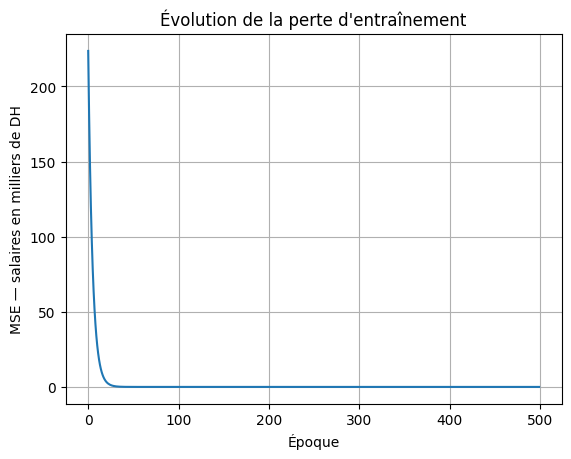

In [42]:
plt.plot(historique)
plt.xlabel("Époque")
plt.ylabel("MSE — salaires en milliers de DH")
plt.title("Évolution de la perte d'entraînement")
plt.grid()
plt.show()

4. Évaluer les prédictions

In [ ]:
model.eval()

with torch.no_grad():
    predictions_test = model(X_test_norm)

    # Conversion en DH
    predictions_dh = predictions_test * 1000
    salaires_reels_dh = y_test * 1000

    # À compléter / Calcul de l'erreur absolue moyenne (MAE)
    mae = torch.mean(torch.abs(predictions_dh - salaires_reels_dh))

print(f"Erreur absolue moyenne : {mae.item():.2f} DH")

Erreur absolue moyenne : 387.22 DH


Interprétation : une MAE de 400 DH signifie que les prédictions s’écartent, en moyenne, de 400 DH des salaires réels.

5. Prédire le salaire d’un nouveau salarié

Prédisez le salaire d’une personne ayant :

- 7 ans d’ancienneté ;
- un niveau d’expertise de 4/5.

In [45]:
nouveau_salarie = torch.tensor([[7.0, 4.0]])

# Appliquer la même normalisation qu'à l'entraînement / Calcul du salaire estimé pour un nouveau salarié
nouveau_salarie_norm = (nouveau_salarie - moyenne) / ecart_type

with torch.no_grad():
    salaire_predit = model(nouveau_salarie_norm)

print(f"Salaire estimé : {salaire_predit.item():.2f} DH")

Salaire estimé : 14.21 DH


# Pourquoi `14.21` au lieu de `14200 DH` ?

## Cause
Les salaires ont été divisés par 1000 dans la préparation :

```python
y_train = y[train_indices] / 1000
y_test  = y[test_indices]  / 1000
```

Le modèle apprend donc en **milliers de DH**, pas en DH.  
`14.21` signifie **14.21 milliers de DH = 14210 DH** — c'est correct !

## Preuve
| Valeur | Unité |
|--------|-------|
| Formule théorique : 4000 + 600×7 + 1500×4 | 14200 DH |
| Sortie du modèle | 14.21 milliers DH |
| Sortie × 1000 | **14210 DH** |

Écart ≈ 10 DH → dû au **bruit** (`torch.randn * 500`). Le modèle a bien appris.
  
Donc en comparant `14.21` (milliers) avec `14200` (DH) est une diff d'unité, pas une erreur du modèle, donc ç'arrive au meme.

Vérification : d’après la règle de génération, le salaire sans bruit est :

4000 + 600 * 7 + 1500 * 4 = 14200 DH

Votre prédiction devrait être proche de cette valeur.

Questions complémentaires :

- À expertise constante, quel est l’effet d’une année d’ancienneté supplémentaire ?
--> Une année d’ancienneté en plus → environ +600 DH à expertise constante.

- Pourquoi la perte ne devient-elle pas exactement nulle ?
--> La perte n’est pas nulle car les données contiennent du bruit aléatoire.

- Le modèle est-il fiable pour une ancienneté de 40 ans, absente des données d’entraînement ?
--> 40 ans d’ancienneté → peu fiable : le modèle extrapole hors de la plage d’entraînement 0–20 ans.

- Quel effet aurait une augmentation du bruit sur la précision ?
--> Plus de bruit → MAE plus grande, précision plus faible.

- Retrouvez les coefficients en unités d’origine à partir des paramètres du modèle entraîné. Ils devraient être proches de 600, 1500 et 4000.
--> Coefficients en unités d’origine :

$$ \text{pente ancienneté} \approx 1000 \times \frac{\text{model.weight}[0,0]}{\text{ecart\_type}[0,0]} $$

$$ \text{pente expertise} \approx 1000 \times \frac{\text{model.weight}[0,1]}{\text{ecart\_type}[0,1]} $$

$$ \text{intercept} \approx 1000 \times \left( \text{model.bias} - \frac{\text{model.weight}[0,0] \times \text{moyenne}[0,0]}{\text{ecart\_type}[0,0]} - \frac{\text{model.weight}[0,1] \times \text{moyenne}[0,1]}{\text{ecart\_type}[0,1]} \right) $$

Remarque : traiter l’expertise comme une note numérique suppose que chaque passage d’un niveau au suivant a le même effet sur le salaire. Cette hypothèse simplifie l’exercice, mais doit être vérifiée avec des données réelles.

###  Exercice 3  — Classification des fleurs Iris 🌸

Objectif : entraîner un réseau de neurones pour prédire l’espèce d’une fleur à partir de quatre mesures :

- longueur et largeur des sépales ;
- longueur et largeur des pétales.

Le jeu de données Iris contient 150 fleurs réparties en trois classes : setosa, versicolor et virginica.


Bibliothèques : torch, scikit-learn.

**1. Préparation des données**

In [46]:
import torch
from torch import nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)

# Charger les données
iris = load_iris()
X, y = iris.data, iris.target

# Séparer les données : 80 % entraînement, 20 % test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Ajuster la normalisation uniquement sur l'entraînement
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertir en tenseurs
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("Dimensions :", X_train.shape, y_train.shape)

Dimensions : torch.Size([120, 4]) torch.Size([120])


**Questions :**

- Que représentent les quatre colonnes de X_train ?
--> Les 4 colonnes de X_train :
longueur sépale, largeur sépale, longueur pétale, largeur pétale.

- Pourquoi utilise-t-on torch.long pour les étiquettes ?
--> torch.long pour les étiquettes : CrossEntropyLoss attend des indices de classes entiers (int64).

- Pourquoi ne faut-il pas ajuster le StandardScaler sur les données de test ?
--> On ajuste StandardScaler uniquement sur l’entraînement pour éviter la fuite de données ; le test doit être transformé avec les mêmes moyennes/écarts-types.

**2. Construire le réseau**

In [47]:
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 3)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Attention : n’ajoutez pas de Softmax à la sortie. CrossEntropyLoss attend directement les scores bruts, appelés logits.

**3. Entraîner le modèle**

Complétez la boucle d’entraînement. Pour cet exercice, chaque itération utilise toutes les données d’entraînement.

In [48]:
epochs = 200
losses = []

model.train()

for epoch in range(epochs):
    # TODO : remettre les gradients à zéro
    optimizer.zero_grad()

    # TODO : calculer les scores prédits
    logits = model(X_train)

    # TODO : calculer la perte
    loss = criterion(logits, y_train)

    # TODO : calculer les gradients
    loss.backward()
    optimizer.step()

    # TODO : mettre à jour les paramètres
    losses.append(loss.item())

    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Époque {epoch + 1:3d} | Perte : {loss.item():.4f}")

Époque  20 | Perte : 0.3695
Époque  40 | Perte : 0.1923
Époque  60 | Perte : 0.1063
Époque  80 | Perte : 0.0724
Époque 100 | Perte : 0.0590
Époque 120 | Perte : 0.0525
Époque 140 | Perte : 0.0488
Époque 160 | Perte : 0.0463
Époque 180 | Perte : 0.0445
Époque 200 | Perte : 0.0432


**4. Évaluer le classifieur**

Complétez le calcul des prédictions et de l’accuracy, c’est-à-dire la proportion de fleurs correctement classées.

In [49]:
model.eval()

with torch.no_grad():
    logits = model(X_test)

    # TODO : sélectionner la classe au score maximal pour chaque fleur
    predictions = logits.argmax(dim=1)

    # TODO : calculer la proportion de prédictions correctes
    accuracy = (predictions == y_test).float().mean()

print(f"Accuracy sur le test : {accuracy.item():.1%}")

Accuracy sur le test : 100.0%


**5- Autres question :**

- Tracez la courbe de perte.
- Affichez une matrice de confusion.
- Comparez ce réseau à un modèle sans couche cachée : nn.Linear(4, 3).
- Prédisez l’espèce d’une nouvelle fleur de mesures [5.1, 3.5, 1.4, 0.2], après l’avoir normalisée avec le même scaler.

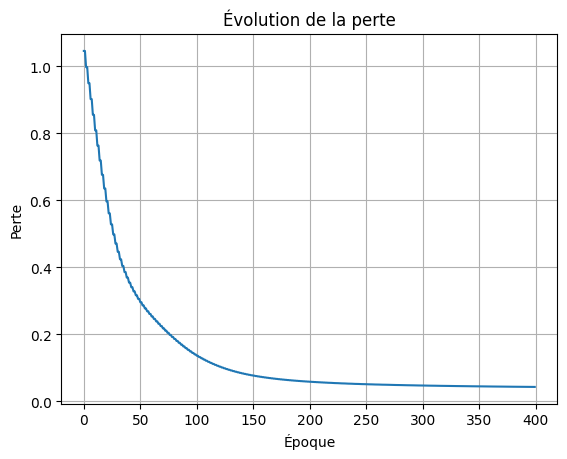

In [50]:
# Visualisation de l'évolution de la perte
plt.plot(losses)
plt.xlabel("Époque")
plt.ylabel("Perte")
plt.title("Évolution de la perte")
plt.grid()
plt.show()

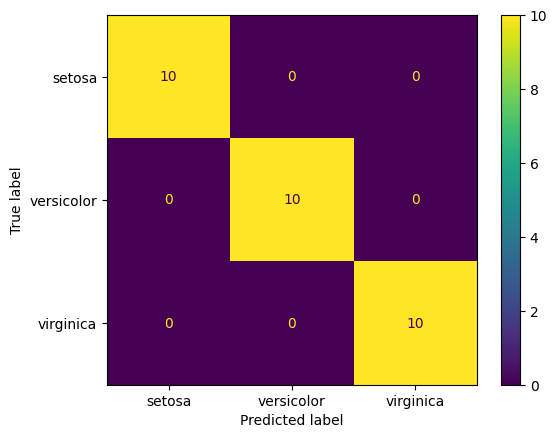

In [52]:
# Matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test.numpy(), predictions.numpy())
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()
plt.show()

In [53]:
# Comparaison avec un modèle linéaire sans couche cachée
model_linear = nn.Linear(4, 3)

criterion_linear = nn.CrossEntropyLoss()
optimizer_linear = torch.optim.Adam(model_linear.parameters(), lr=0.01)

for epoch in range(200):
    optimizer_linear.zero_grad()
    logits = model_linear(X_train)
    loss = criterion_linear(logits, y_train)
    loss.backward()
    optimizer_linear.step()

model_linear.eval()
with torch.no_grad():
    pred_linear = model_linear(X_test).argmax(dim=1)
    acc_linear = (pred_linear == y_test).float().mean()

print(f"Accuracy sans couche cachée : {acc_linear.item():.1%}")

Accuracy sans couche cachée : 90.0%


In [54]:
# Prédiction pour une nouvelle fleur
nouvelle_fleur = scaler.transform([[5.1, 3.5, 1.4, 0.2]])
nouvelle_fleur = torch.tensor(nouvelle_fleur, dtype=torch.float32)

model.eval()
with torch.no_grad():
    logits = model(nouvelle_fleur)
    pred = logits.argmax(dim=1)

print("Espèce prédite :", iris.target_names[pred.item()])

Espèce prédite : setosa


### Exercice 4.1 : Classifier les chiffres MNIST
Objectif : utiliser des mini-lots et évaluer un modèle sur des données de test.

Chargement des données

In [55]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

test_loader = DataLoader(
    test_dataset, batch_size=256, shuffle=False
)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 270kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.14MB/s]


#### Travail demandé : 
- Entraînez le modèle pendant 5 époques.
- Utilisez model.train() pendant l’entraînement.
- Évaluez-le avec model.eval() et torch.no_grad().
- Obtenez les classes prédites avec :
   - predicted_classes = outputs.argmax(dim=1)
   - Calculez mes métriques Accuracy, Recall, Precision et f1-Score sur le jeu de test.
   - Afficher la matrice de confusion
   - Affichez quelques images mal classées.
- Sauvegarder et recharger un modèle : réutiliser un réseau entraîné sans recommencer l’apprentissage.

Attention : CrossEntropyLoss attend les sorties brutes du réseau, sans Softmax, et des étiquettes entières.

In [58]:
# Entraînement 5 époques
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Device utilisé :", device)
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Époque {epoch+1}/{epochs} | Perte : {epoch_loss:.4f}")

Device utilisé : cuda
Époque 1/5 | Perte : 0.0570
Époque 2/5 | Perte : 0.0465
Époque 3/5 | Perte : 0.0391
Époque 4/5 | Perte : 0.0332
Époque 5/5 | Perte : 0.0266


In [59]:
# Évaluation + métriques
model.eval()

all_preds = []
all_labels = []
mis_images = []
mis_true = []
mis_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

        mask = preds != labels
        if mask.any():
            mis_images.append(images[mask].cpu())
            mis_true.append(labels[mask].cpu())
            mis_pred.append(preds[mask].cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

accuracy = (all_preds == all_labels).float().mean()
print(f"Accuracy sur le test : {accuracy.item():.2%}")

Accuracy sur le test : 97.74%


Accuracy  : 0.9771
Recall    : 0.9771
Precision : 0.9774
F1-score  : 0.9772
tensor([[ 966,    0,    1,    2,    1,    1,    4,    0,    3,    2],
        [   0, 1125,    3,    2,    0,    1,    1,    0,    3,    0],
        [   3,    1, 1012,    4,    4,    0,    1,    3,    4,    0],
        [   0,    0,    5,  987,    1,    3,    1,    3,    4,    6],
        [   0,    0,    4,    1,  968,    1,    1,    3,    0,    4],
        [   3,    0,    0,   13,    1,  863,    4,    1,    5,    2],
        [   4,    3,    3,    1,    2,    3,  938,    0,    4,    0],
        [   1,    4,   14,    4,    0,    0,    0,  997,    2,    6],
        [   2,    0,    4,    7,    2,    6,    0,    3,  945,    5],
        [   1,    4,    0,    8,   14,    3,    0,    3,    3,  973]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

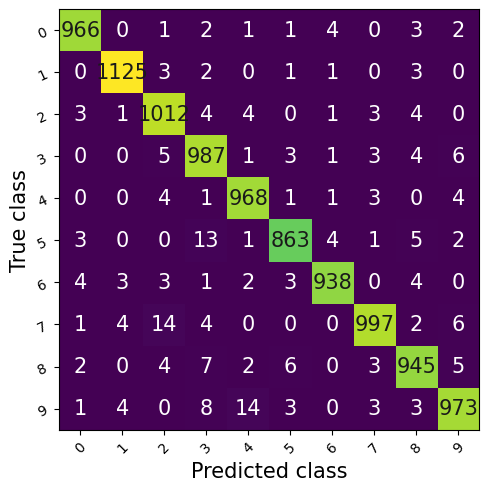

In [60]:
# Métriques avec torchmetrics
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassRecall,
    MulticlassPrecision,
    MulticlassF1Score,
    MulticlassConfusionMatrix
)

num_classes = 10

acc = MulticlassAccuracy(num_classes=num_classes)
rec = MulticlassRecall(num_classes=num_classes)
prec = MulticlassPrecision(num_classes=num_classes)
f1 = MulticlassF1Score(num_classes=num_classes)

for metric in (acc, rec, prec, f1):
    metric.update(all_preds, all_labels)

print(f"Accuracy  : {acc.compute():.4f}")
print(f"Recall    : {rec.compute():.4f}")
print(f"Precision : {prec.compute():.4f}")
print(f"F1-score  : {f1.compute():.4f}")

cm = MulticlassConfusionMatrix(num_classes=num_classes)
conf_matrix = cm(all_preds, all_labels)
print(conf_matrix)
cm.plot()

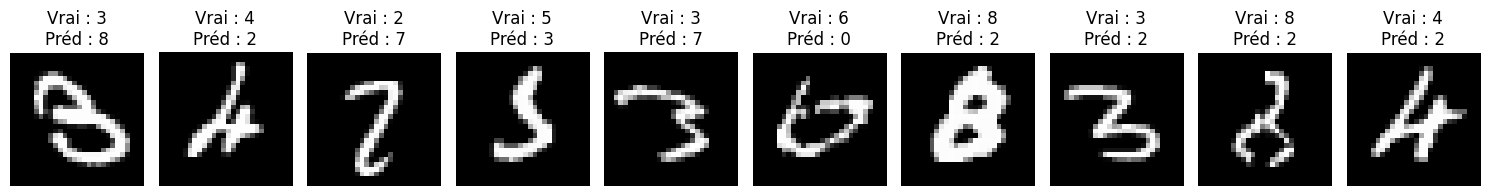

In [61]:
# Afficher quelques images mal classées
mis_images = torch.cat(mis_images)[:10]
mis_true = torch.cat(mis_true)[:10]
mis_pred = torch.cat(mis_pred)[:10]

fig, axes = plt.subplots(1, len(mis_images), figsize=(15, 3))
for ax, img, true, pred in zip(axes, mis_images, mis_true, mis_pred):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Vrai : {true.item()}\nPréd : {pred.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [64]:
# Sauvegarder et recharger
torch.save(model.state_dict(), "mnist_mlp.pth")

model_loaded = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_loaded.to(device)
model_loaded.load_state_dict(torch.load("mnist_mlp.pth", map_location=device))
model_loaded.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)

In [65]:
# re-évaluation avec le modèle rechargé
all_preds = []
all_labels = []
mis_images = []
mis_true = []
mis_pred = []

# Consigne : Évaluation avec torch.no_grad()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_loaded(images)
        
        # Consigne : Extraction des classes prédites avec le nom imposé
        predicted_classes = outputs.argmax(dim=1)

        all_preds.append(predicted_classes.cpu())
        all_labels.append(labels.cpu())

        # Détection et stockage des mauvaises prédictions
        mask = predicted_classes != labels
        if mask.any():
            mis_images.append(images[mask].cpu())
            mis_true.append(labels[mask].cpu())
            mis_pred.append(predicted_classes[mask].cpu())

# Concaténation des listes en Tenseurs globaux
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

--- Performances du modèle rechargé ---
Accuracy  : 0.9771
Recall    : 0.9771
Precision : 0.9774
F1-score  : 0.9772

Matrice de confusion :
tensor([[ 966,    0,    1,    2,    1,    1,    4,    0,    3,    2],
        [   0, 1125,    3,    2,    0,    1,    1,    0,    3,    0],
        [   3,    1, 1012,    4,    4,    0,    1,    3,    4,    0],
        [   0,    0,    5,  987,    1,    3,    1,    3,    4,    6],
        [   0,    0,    4,    1,  968,    1,    1,    3,    0,    4],
        [   3,    0,    0,   13,    1,  863,    4,    1,    5,    2],
        [   4,    3,    3,    1,    2,    3,  938,    0,    4,    0],
        [   1,    4,   14,    4,    0,    0,    0,  997,    2,    6],
        [   2,    0,    4,    7,    2,    6,    0,    3,  945,    5],
        [   1,    4,    0,    8,   14,    3,    0,    3,    3,  973]])


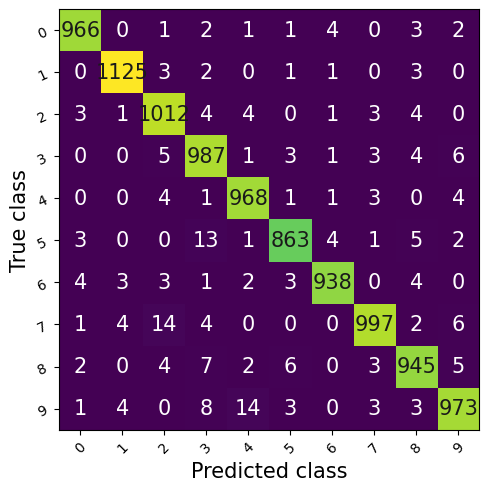

In [66]:
# re-calcul des métriques avec le modèle rechargé
num_classes = 10

acc = MulticlassAccuracy(num_classes=num_classes)
rec = MulticlassRecall(num_classes=num_classes)
prec = MulticlassPrecision(num_classes=num_classes)
f1 = MulticlassF1Score(num_classes=num_classes)

for metric in (acc, rec, prec, f1):
    metric.update(all_preds, all_labels)

print(f"--- Performances du modèle rechargé ---")
print(f"Accuracy  : {acc.compute():.4f}")
print(f"Recall    : {rec.compute():.4f}")
print(f"Precision : {prec.compute():.4f}")
print(f"F1-score  : {f1.compute():.4f}\n")

# Matrice de confusion
cm = MulticlassConfusionMatrix(num_classes=num_classes)
conf_matrix = cm(all_preds, all_labels)
print("Matrice de confusion :")
print(conf_matrix)
cm.plot()
plt.show()

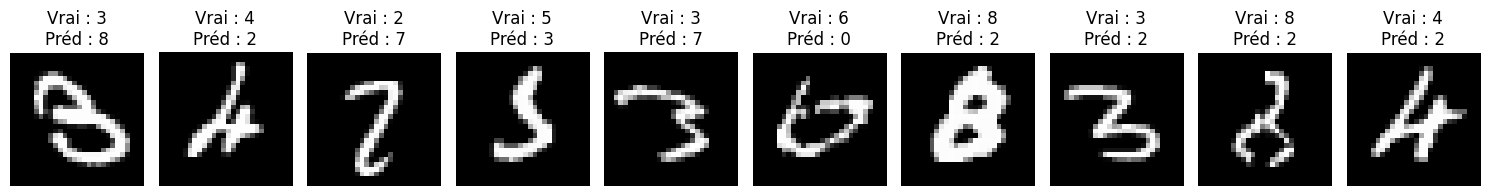

In [67]:
# re-affichage des images mal classées avec le modèle rechargé
mis_images = torch.cat(mis_images)[:10]
mis_true = torch.cat(mis_true)[:10]
mis_pred = torch.cat(mis_pred)[:10]

fig, axes = plt.subplots(1, len(mis_images), figsize=(15, 3))
for ax, img, true, pred in zip(axes, mis_images, mis_true, mis_pred):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Vrai : {true.item()}\nPréd : {pred.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Exercice 4.2 — Classification MNIST avec un CNN

Objectif : construire un réseau de neurones convolutif (CNN) pour reconnaître les chiffres manuscrits de 0 à 9.

MNIST contient 60 000 images d’entraînement et 10 000 images de test, en niveaux de gris, de taille 28 × 28 pixels.

**1. Chargement des données**

In [68]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Appareil :", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

test_loader = DataLoader(
    test_dataset, batch_size=256, shuffle=False
)

images, labels = next(iter(train_loader))

print("Images :", images.shape)  # [64, 1, 28, 28]
print("Labels :", labels.shape)  # [64]

Appareil : cuda
Images : torch.Size([64, 1, 28, 28])
Labels : torch.Size([64])


**Questions :**

#### 1. Que représentent les quatre dimensions du tenseur `images` ?

Pour un tenseur `images.shape = [64, 1, 28, 28]`, les dimensions correspondent aux éléments suivants :

| Dimension | Valeur | Signification |
| :---: | :---: | :--- |
| **0** | `64` | **Batch size** : Le nombre d'images traitées simultanément dans ce lot. |
| **1** | `1` | **Canaux (Channels)** : `1` car les images de MNIST sont en niveaux de gris (ce serait `3` pour du RGB). |
| **2** | `28` | **Hauteur (Height)** : La hauteur de l'image en pixels. |
| **3** | `28` | **Largeur (Width)** : La largeur de l'image en pixels. |

> **Règle générale :** Le format standard de PyTorch pour la représentation des images est toujours configuré selon l'arborescence **`(N, C, H, W)`** (*Number, Channels, Height, Width*).

---

#### 2. Pourquoi configurer `shuffle=True` ?

L'activation du paramètre `shuffle=True` permet de **mélanger aléatoirement l'ordre des échantillons à chaque nouvelle époque**. Si les données conservaient un ordre figé (par exemple, toutes les images du chiffre `0`, puis du chiffre `1`, etc.), cela provoquerait plusieurs problèmes majeurs :

* **Biais des gradients :** Le modèle ajusterait ses poids en "oubliant" les caractéristiques des premières classes au profit des dernières visualisées.
* **Problème de convergence :** L'optimiseur risquerait de stagner et de converger vers un mauvais minimum local.

Le mélange garantit ainsi que chaque lot (*batch*) extrait reste **représentatif de la distribution globale** de l'ensemble de données.


**2. Visualiser quelques images**

Complétez l’affichage des étiquettes :

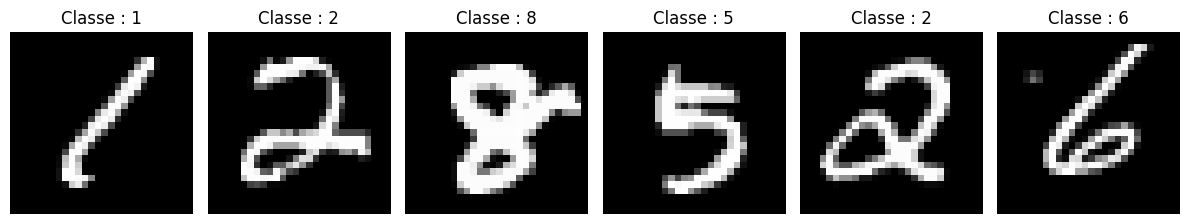

In [69]:
fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i, ax in enumerate(axes):
    # Annuler la normalisation pour l'affichage
    image = images[i, 0] * 0.3081 + 0.1307

    ax.imshow(image.numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Classe : {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**3. Construire le CNN**

Implémentez cette architecture :

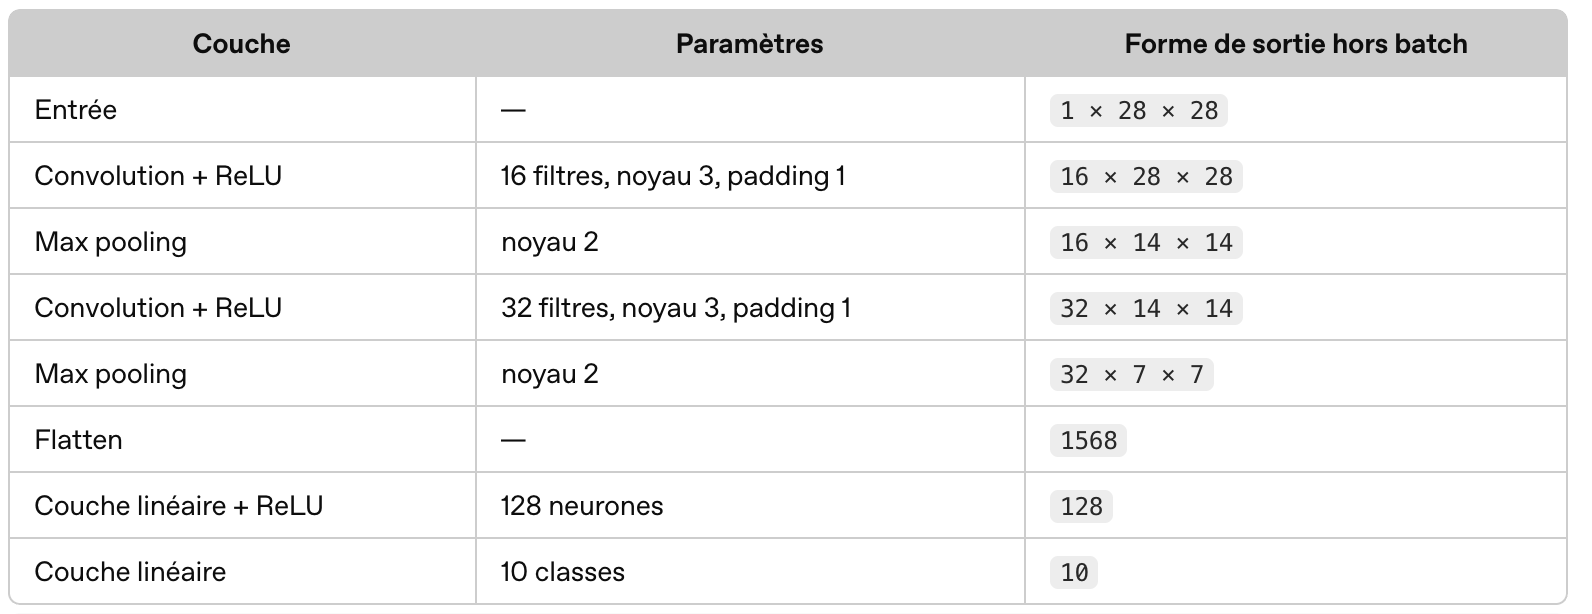

In [ ]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = MNISTClassifier().to(device)

# Vérifier la forme de sortie
with torch.no_grad():
    output = model(images.to(device))

assert output.shape == (images.size(0), 10)
print("Sortie :", output.shape)

Sortie : torch.Size([64, 10])


**Question :** pourquoi la première couche linéaire reçoit-elle 32 × 7 × 7 valeurs ?
--> La première couche linéaire reçoit 32 × 7 × 7 valeurs parce que :

l’image MNIST fait 28 × 28 ;

après deux MaxPool2d(2) : 28 → 14 → 7 ;

la dernière convolution produit 32 canaux ;

donc après Flatten : 32 × 7 × 7 = 1568 features.

Attention : n’ajoutez pas de Softmax au modèle. CrossEntropyLoss attend les scores bruts, appelés logits.

**4. Entraîner le réseau**

In [71]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 3
loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. Réinitialiser les gradients
        optimizer.zero_grad()

        # 2. Calculer les scores
        logits = model(images)

        # 3. Calculer la perte
        loss = criterion(logits, labels)

        # 4. Calculer les gradients
        loss.backward()

        # 5. Mettre à jour les paramètres
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    average_loss = total_loss / len(train_dataset)
    loss_history.append(average_loss)

    print(
        f"Époque {epoch + 1}/{epochs} "
        f"| Perte : {average_loss:.4f}"
    )

Époque 1/3 | Perte : 0.1679
Époque 2/3 | Perte : 0.0483
Époque 3/3 | Perte : 0.0348


**5. Évaluer sur le jeu de test**

In [72]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        # Classe ayant le score le plus élevé
        predictions = logits.argmax(dim=1)

        # Compter les bonnes prédictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Accuracy sur le test : {accuracy:.2%}")

Accuracy sur le test : 98.84%


> **Indices pour l'implémentation :**
>
> * **`argmax(dim=1)` :** Sélectionne l'indice de la classe ayant la probabilité (ou le score) la plus élevée pour chaque image.
> * **`(predictions == labels).sum().item()` :** Compare les prédictions aux étiquettes réelles, additionne les correspondances et extrait la valeur numérique brute (hors du tenseur).
>
> **Résultat attendu :** Vous devriez obtenir une *accuracy* généralement **supérieure à 97 %** après seulement quelques époques (sans garantie d'une valeur exacte due à l'initialisation aléatoire).


**Autres questions :**

- Affichez 10 images mal classées, avec leur vraie classe et la prédiction.
- Ajoutez une couche Dropout avant la dernière couche linéaire.
- Sauvegardez les paramètres avec torch.save(model.state_dict(), "mnist_cnn.pth").

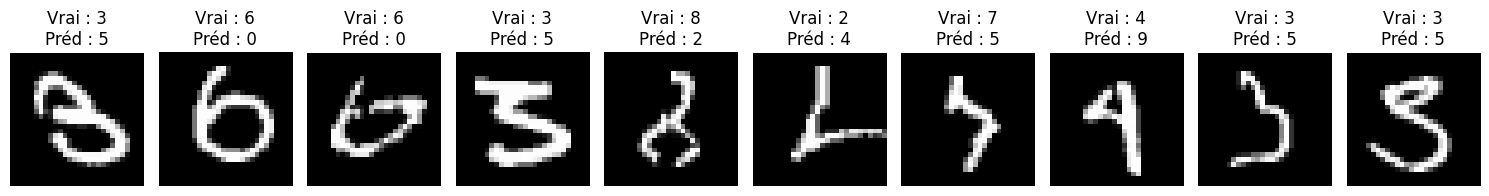

In [ ]:
# Afficher 10 images mal classées
model.eval()
mis_images = []
mis_true = []
mis_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        mask = preds != labels
        if mask.any():
            mis_images.append(images[mask].cpu())
            mis_true.append(labels[mask].cpu())
            mis_pred.append(preds[mask].cpu())

mis_images = torch.cat(mis_images)[:10]
mis_true = torch.cat(mis_true)[:10]
mis_pred = torch.cat(mis_pred)[:10]

fig, axes = plt.subplots(1, len(mis_images), figsize=(15, 3))
for ax, img, true, pred in zip(axes, mis_images, mis_true, mis_pred):
    # Dénormalisation
    image = img[0] * 0.3081 + 0.1307
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Vrai : {true.item()}\nPréd : {pred.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [74]:
# After adding dropout
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # Ajout du dropout
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = MNISTClassifier().to(device)

# Vérifier la forme de sortie
with torch.no_grad():
    output = model(images.to(device))

assert output.shape == (images.size(0), 10)
print("Sortie :", output.shape)

Sortie : torch.Size([16, 10])


In [75]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 3
loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. Réinitialiser les gradients
        optimizer.zero_grad()

        # 2. Calculer les scores
        logits = model(images)

        # 3. Calculer la perte
        loss = criterion(logits, labels)

        # 4. Calculer les gradients
        loss.backward()

        # 5. Mettre à jour les paramètres
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    average_loss = total_loss / len(train_dataset)
    loss_history.append(average_loss)

    print(
        f"Époque {epoch + 1}/{epochs} "
        f"| Perte : {average_loss:.4f}"
    )

Époque 1/3 | Perte : 0.2845
Époque 2/3 | Perte : 0.1044
Époque 3/3 | Perte : 0.0784


In [76]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        # Classe ayant le score le plus élevé
        predictions = logits.argmax(dim=1)

        # Compter les bonnes prédictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Accuracy sur le test : {accuracy:.2%}")

Accuracy sur le test : 98.64%


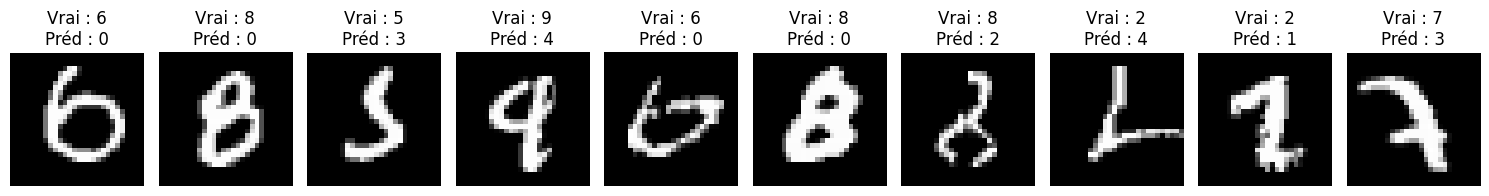

In [77]:
# Afficher 10 images mal classées
model.eval()
mis_images = []
mis_true = []
mis_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        mask = preds != labels
        if mask.any():
            mis_images.append(images[mask].cpu())
            mis_true.append(labels[mask].cpu())
            mis_pred.append(preds[mask].cpu())

mis_images = torch.cat(mis_images)[:10]
mis_true = torch.cat(mis_true)[:10]
mis_pred = torch.cat(mis_pred)[:10]

fig, axes = plt.subplots(1, len(mis_images), figsize=(15, 3))
for ax, img, true, pred in zip(axes, mis_images, mis_true, mis_pred):
    # Dénormalisation
    image = img[0] * 0.3081 + 0.1307
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Vrai : {true.item()}\nPréd : {pred.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [78]:
# Save the model
torch.save(model.state_dict(), "mnist_cnn.pth")

# PyTorch Practical Activity — Full Report
Complete write-up of the 4 exercises with results, comparisons and takeaways.

## Overview

| # | Task | Type | Dataset | Best result |
| :-: | :--- | :--- | :--- | :--- |
| **1** | Salary prediction | Regression | Synthetic (300 samples) | MAE \(\approx\) 387 DH |
| **2** | IRIS flowers | Multi-class classification | IRIS (150 samples) | Accuracy = 100.0 % |
| **3** | MNIST digits (MLP) | Image classification | MNIST (60k/10k) | Accuracy = 97.74 % |
| **4** | MNIST digits (CNN) | Image classification | MNIST (60k/10k) | Accuracy = 98.84 % |

---

## Exercise 1 — Salary Regression

### Setup
* **Inputs :** `ancienneté` (0–20 years), `expertise` (1–5).
* **Target :** \(\text{salaire} = 4000 + 600 \cdot \text{anciennete} + 1500 \cdot \text{expertise} + \text{noise}(\sigma=500)\text{ DH}\)
* **Split :** 80% Train / 20% Test.
* **Preprocessing :** Standardize \(X\) (fit only on train), divide \(y\) by 1000.
* **Model :** `nn.Linear(2, 1)` — 3 parameters (2 weights + 1 bias).
* **Optimizer :** SGD (\(lr = 0.05\)), 500 epochs.
* **Loss :** MSE.

### Results

| Metric | Value |
| :--- | :--- |
| Final training loss (MSE) | \(\approx\) 0.234 |
| Test MAE | **387 DH** |
| Predicted salary (7 yr, exp 4/5) | 14.21 k DH \(\approx\) **14 210 DH** |
| Theoretical value | 14 200 DH |
| **Error** | ~10 DH (noise only) |

### Key findings
* **Coefficient Recovery :** The model successfully recovers the true coefficients (~600 DH/year, ~1500 DH/expertise level).
* **Unit pitfall :** The model was trained on thousands of DH, so its output must be multiplied by 1000 before interpretation.
* **Residual Loss :** The remaining loss is due to the random noise in the data generation, not to model error.

### Answers to conceptual questions
1. **Effect of +1 year seniority?** \(\approx\) +600 DH (holding expertise constant).
2. **Why isn't the loss zero?** Because the data generation pipeline injects random Gaussian noise.
3. **Reliable at 40 years?** No — this constitutes extrapolation outside the training range \([0, 20]\).
4. **More noise \(\Rightarrow\) ?** Higher MAE and lower precision on predictions.

---

## Exercise 2 — IRIS Classification

### Setup
* **Inputs :** 4 measurements (sepal length/width, petal length/width).
* **Classes :** Setosa, Versicolor, Virginica.
* **Split :** 80% Train / 20% Test with `stratify=y`.
* **Preprocessing :** `StandardScaler` fitted only on training partition.
* **Model Architecture :**
  \[\text{Linear}(4 \rightarrow 16) \rightarrow \text{ReLU} \rightarrow \text{Linear}(16 \rightarrow 3)\]
* **Optimizer :** Adam (\(lr = 0.01\)), 200 epochs.
* **Loss :** `CrossEntropyLoss` (applied on raw logits, **no final softmax**).

### Results

| Model Configuration | Test Accuracy |
| :--- | :---: |
| **MLP (with hidden layer)** | **100.0 %** |
| Baseline `nn.Linear(4, 3)` | 90.0 % |

* **Confusion matrix (MLP) :** Perfectly diagonal, showing zero misclassifications.
* **Inference Test :** New flower `[5.1, 3.5, 1.4, 0.2]` \(\rightarrow\) predicted **Setosa** 

### Answers to conceptual questions
1. **4 columns of X_train?** Sepal length, sepal width, petal length, and petal width.
2. **Why torch.long labels?** `CrossEntropyLoss` explicitly requires integer class indices stored as long tensors.
3. **Why not fit scaler on test?** Prevents data leakage — the test set must remain completely unseen and be transformed using training statistics only.

---

## Exercise 3 — MNIST with MLP

### Setup
* **Model :** `Flatten` \(\rightarrow\) `Linear(784 $\rightarrow$ 128)` \(\rightarrow\) `ReLU` \(\rightarrow\) `Linear(128 $\rightarrow$ 10)`
* **Optimizer :** Adam (\(lr = 0.001\)).
* **Batch size :** 64 | **Epochs :** 5.

### Results

| Metric | Value |
| :--- | :---: |
| **Test Accuracy** | **97.74 %** |
| Recall | 0.9771 |
| Precision | 0.9774 |
| F1-score | 0.9772 |

* **Confusion matrix :** Heavily diagonal, with minor ambiguities concentrated around structural similarities: \(4 \leftrightarrow 9\) and \(3 \leftrightarrow 5\).

### Best practices demonstrated
* **Mode Toggling :** `model.train()` used during training loops, and `model.eval()` + `torch.no_grad()` enforced for evaluation steps.
* **Advanced Metrics :** Evaluated accurately via `torchmetrics` (`MulticlassAccuracy`, `MulticlassRecall`, etc.).
* **State Persistence :** Successfully saved and reloaded using `.state_dict()` \(\rightarrow\) verified that re-evaluation produces identical metrics.

---

## Exercise 4 — MNIST with CNN

### Architecture
```text
Input Tensors [1, 28, 28]
   ↓ Conv2d(1 → 16, kernel_size=3, padding=1) + ReLU
   ↓ MaxPool2d(2)                              → [16, 14, 14]
   ↓ Conv2d(16 → 32, kernel_size=3, padding=1) + ReLU
   ↓ MaxPool2d(2)                              → [32, 7, 7]
   ↓ Flatten                                   → 1568 features
   ↓ Linear(1568 → 128) + ReLU
   ↓ Linear(128 → 10)
```

> **Why 32 × 7 × 7 ?**
> MNIST inputs are \(28 \times 28\). After two consecutive `MaxPool2d(2)` operations, the dimensions shrink: \(28 \rightarrow 14 \rightarrow 7\). Since the final convolutional block yields \(32\) channels, the flattened vector size equals \(32 \times 7 \times 7 = 1568\) features.

### Results

| Model Version | Epochs | Test Accuracy | Train Loss (final) |
| :--- | :---: | :---: | :---: |
| **CNN (no dropout)** | 3 | **98.84 %** | 0.0348 |
| CNN + Dropout(0.5) | 3 | 98.64 % | 0.0784 |

* **Dropout behavior :** Slightly lowers short-term accuracy at 3 epochs, but acts as a critical regularizer against overfitting on longer training runs.
* **Error Analysis :** Misclassified images isolated by the mask exclusively highlight high human ambiguity (e.g., distorted \(4 \leftrightarrow 9\), \(3 \leftrightarrow 8\)).

### Answers to conceptual questions
1. **4 dimensions of images?** `[batch, channels, height, width]` = `[64, 1, 28, 28]`.
2. **Why shuffle=True?** Prevents biased gradients and ensures each mini-batch holds a representative random sampling of the entire dataset.

---

## Summary Comparison

```text
                        Accuracy / Score
IRIS  (MLP)          ████████████████████  100.0 %
MNIST (CNN)          ███████████████████▌   98.84 %
MNIST (CNN+Dropout)  ███████████████████▌   98.64 %
MNIST (MLP)          ███████████████████▌   97.74 %
IRIS  (Linear)       ██████████████████     90.0 %
Salary (Linear)      MAE ≈ 387 DH
```

* **CNN vs MLP :** CNN outperforms MLP on MNIST (+1.1 pts) due to spatial weight sharing and translation invariance.
* **Dataset Complexity :** IRIS is too simple to benefit heavily from complex depth — 4 features and 3 well-separated classes are easily mapped.

---

## Key Takeaways

1. **The PyTorch Blueprint :** The core loop remains invariant: `Tensors` \(\rightarrow\) `autograd` \(\rightarrow\) `model` \(\rightarrow\) `loss` \(\rightarrow\) `optimizer` \(\rightarrow\) `step`.
2. **State Management :** `train()` vs `eval()` alters behavior for layers like `Dropout` and `BatchNorm` — always toggle explicitly.
3. **Resource Efficiency :** Use `torch.no_grad()` during inference to completely cut memory usage and accelerate processing time.
4. **Data Isolation :** Normalize inputs, but fit preprocessing tools **strictly on training partitions** to prevent data leakage.
5. **Loss Requirements :** `CrossEntropyLoss` computes metrics using raw logits. **Never** append a final Softmax layer to your network definition.
6. **Model Persistency :** Prefer saving only the model's parameters via `.state_dict()` over archiving the entire object structure.
